In [168]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, scale
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn import model_selection

In [169]:
df = pd.read_csv('parkinson_data.txt', sep=',', header = None)
print(df.head())

   0      1         2      3      4      5       6      7      8      9   ...  \
0   1  1.488  0.000090  0.900  0.794  2.699   8.334  0.779  4.517  4.609  ...   
1   1  0.728  0.000038  0.353  0.376  1.059   5.864  0.642  2.058  3.180  ...   
2   1  1.220  0.000074  0.732  0.670  2.196   8.719  0.875  4.347  5.166  ...   
3   1  2.502  0.000123  1.156  1.634  3.469  13.513  1.273  5.263  8.771  ...   
4   1  3.509  0.000167  1.715  1.539  5.145   9.112  1.040  3.102  4.927  ...   

        19    20    21        22        23      24  25      26  27  28  
0  187.576   160   159  0.006065  0.000416   0.000   0   0.000  23   1  
1  234.505   170   169  0.005181  0.000403   2.247   0   0.000  23   1  
2  211.442  1431  1427  0.006071  0.000474  10.656   1   0.178  23   1  
3  220.230    94    92  0.004910  0.000320   0.000   0   0.000  23   1  
4  225.162   117   114  0.004757  0.000380  18.182   1  13.318  23   1  

[5 rows x 29 columns]


In [170]:
# Rename column
columns = ['subject_id'] + [f'feature_{i}' for i in range(1,27)] + ['UPDRS', 'class']
df.columns = columns
df.columns

Index(['subject_id', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24',
       'feature_25', 'feature_26', 'UPDRS', 'class'],
      dtype='object')

In [171]:
# omit independent variable
X = df.drop(['subject_id','UPDRS','class'], axis=1).values
y = df['UPDRS'].values

In [172]:
# create alpha value
alphas = 10**np.linspace(-2, 2, 100)
alphas

array([1.00000000e-02, 1.09749877e-02, 1.20450354e-02, 1.32194115e-02,
       1.45082878e-02, 1.59228279e-02, 1.74752840e-02, 1.91791026e-02,
       2.10490414e-02, 2.31012970e-02, 2.53536449e-02, 2.78255940e-02,
       3.05385551e-02, 3.35160265e-02, 3.67837977e-02, 4.03701726e-02,
       4.43062146e-02, 4.86260158e-02, 5.33669923e-02, 5.85702082e-02,
       6.42807312e-02, 7.05480231e-02, 7.74263683e-02, 8.49753436e-02,
       9.32603347e-02, 1.02353102e-01, 1.12332403e-01, 1.23284674e-01,
       1.35304777e-01, 1.48496826e-01, 1.62975083e-01, 1.78864953e-01,
       1.96304065e-01, 2.15443469e-01, 2.36448941e-01, 2.59502421e-01,
       2.84803587e-01, 3.12571585e-01, 3.43046929e-01, 3.76493581e-01,
       4.13201240e-01, 4.53487851e-01, 4.97702356e-01, 5.46227722e-01,
       5.99484250e-01, 6.57933225e-01, 7.22080902e-01, 7.92482898e-01,
       8.69749003e-01, 9.54548457e-01, 1.04761575e+00, 1.14975700e+00,
       1.26185688e+00, 1.38488637e+00, 1.51991108e+00, 1.66810054e+00,
      

In [173]:
ridge = Ridge()
coefs = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)

np.shape(coefs)

(100, 26)

In [174]:
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# scale transformation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [175]:
# Ridge regression
# create alpha value
alphas = 10**np.linspace(-2, 2, 100)

# find optimal alpha using ridgecv
ridgecv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
ridgecv.fit(X_train_scaled, y_train)

# fit ridge model using best alpha
ridge = Ridge(alpha=ridgecv.alpha_)
ridge.fit(X_train_scaled, y_train)

# Prediction
ridge_pred = ridge.predict(X_test_scaled)

# calculate mse
ridge_mse = mean_squared_error(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Best alpha:", ridgecv.alpha_)

Ridge MSE: 204.37143292324785
Best alpha: 75.64633275546291


In [176]:
# Lasso Regression

lasso = Lasso(max_iter=10000)

lassocv = LassoCV(alphas=alphas, cv=10, max_iter=100000)
lassocv.fit(X_train_scaled, y_train)

lasso.set_params(alpha=lassocv.alpha_)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("LASSO MSE:", lasso_mse)
print("Best alpha:", lassocv.alpha_)

LASSO MSE: 207.62224063620482
Best alpha: 0.13530477745798075


In [177]:
# check selected variable
lasso_coef = pd.Series(lasso.coef_,index=df.drop(['subject_id','UPDRS','class'], axis=1).columns)
lasso_coef

feature_1    -0.000000
feature_2     2.509278
feature_3     2.111712
feature_4    -0.000000
feature_5     0.015318
feature_6     0.000000
feature_7     0.000000
feature_8    -0.131812
feature_9     0.000000
feature_10    3.046791
feature_11   -0.064436
feature_12    0.000000
feature_13   -3.598066
feature_14   -1.156130
feature_15   -0.000000
feature_16   -3.417019
feature_17   -0.000000
feature_18   -0.000000
feature_19   -0.000000
feature_20    0.000000
feature_21    1.820103
feature_22   -2.811385
feature_23   -0.969313
feature_24    1.116914
feature_25   -0.745684
feature_26   -0.968996
dtype: float64

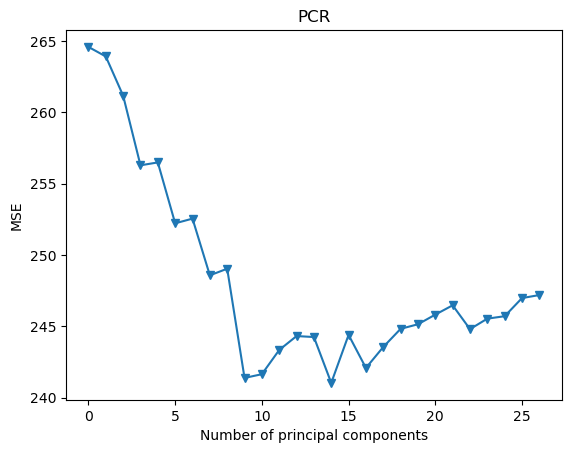

In [178]:
#PCR
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Apply PCA on training data
pca2 = PCA()
X_reduced_train = pca2.fit_transform(scale(X_train))

# no of training observed
n = len(X_reduced_train)

# 10-fold cross validation
kf_10 = model_selection.KFold(n_splits=10, shuffle=True, random_state=1)

regr = LinearRegression()
mse = []

# mse with intercept only model
score = -1 *model_selection.cross_val_score(regr,np.ones((n,1)),y_train,cv=kf_10,scoring='neg_mean_squared_error').mean()
mse.append(score)

# PCR for different number of components
for i in np.arange(1, 27):
    score = -1 * model_selection.cross_val_score(regr,X_reduced_train[:, :i],y_train,cv=kf_10,scoring='neg_mean_squared_error').mean()
    mse.append(score)

plt.plot(np.array(mse), '-v')
plt.xlabel('Number of principal components')
plt.ylabel('MSE')
plt.title('PCR')
plt.show()

In [179]:
# check amount of var explained
np.cumsum(np.round(pca2.explained_variance_ratio_, decimals=4) * 100)

array([40.33, 57.49, 67.59, 76.61, 83.1 , 87.59, 90.19, 92.25, 94.07,
       95.04, 95.91, 96.68, 97.28, 97.84, 98.33, 98.78, 99.17, 99.51,
       99.75, 99.84, 99.91, 99.96, 99.97, 99.97, 99.97, 99.97])

In [180]:
for pc in [9, 14]:
    X_test_pc = pca2.transform(scale(X_test))[:, :pc]
    
    model = LinearRegression()
    model.fit(X_reduced_train[:, :pc], y_train)
    
    pred = model.predict(X_test_pc)
    mse_val = mean_squared_error(y_test, pred)
    
    print("PCR MSE (",pc,"PCs):", mse_val)

PCR MSE ( 9 PCs): 202.71225180738512
PCR MSE ( 14 PCs): 202.29637371594674


In [181]:
# performance of test data
# fit model until 14pc
X_reduced_test = pca2.transform(scale(X_test))[:, :14]

# final PCR model
pcr_model = LinearRegression()
pcr_model.fit(X_reduced_train[:, :14], y_train)

# prediction
pcr_pred = pcr_model.predict(X_reduced_test)

# calculate mse
pcr_mse = mean_squared_error(y_test, pcr_pred)

print("PCR MSE:", pcr_mse)

PCR MSE: 202.29637371594674


In [182]:
print("\nFinal Comparison:")
print("Ridge MSE:", ridge_mse)
print("LASSO MSE:", lasso_mse)
print("PCR MSE:", pcr_mse) # has the lowest mse


Final Comparison:
Ridge MSE: 204.37143292324785
LASSO MSE: 207.62224063620482
PCR MSE: 202.29637371594674


## Discussion

Based on the results, PCR has the lowest MSE (202.30) which suggests that it performs slightly better in predicting the UPDRS score compared to Ridge (204.37) and LASSO (207.62). Ridge regression helps to reduce overfitting by shrinking while LASSO simplifies model by setting coefficients to zero by selecting important features. PCR reduces number of predictors by transforming them into principal components.

For PCR, the number of principal components was selected based on the cv results. Principal component 9 might explain a large portion of the variance but principal component 14 gave a lower mse indicating a better predictive performance. However, testing showed that using principal component 9 resulted in a very similar MSE (202.71), suggesting that a simpler model can still perform well.

In conclusion, PCR outperformed both Ridge and LASSO in this study with the lowest test MSE and become the optimal model. Ridge performed slightly worse but still gave a slight difference value which is competitive result, while LASSO had the highest MSE among the three. This shows that dimensionality reduction through PCR is effective for this dataset.